Mounted at /content/drive

Training SVM...
SVM Accuracy: 0.9517

Training Logistic Regression...
Logistic Regression Accuracy: 0.9370

Training Naive Bayes...
Naive Bayes Accuracy: 0.8896

Training Random Forest...
Random Forest Accuracy: 0.9034

Training XGBoost...
XGBoost Accuracy: 0.9457

📊 Model Comparison:

SVM: 0.9517
Logistic Regression: 0.9370
Naive Bayes: 0.8896
Random Forest: 0.9034
XGBoost: 0.9457

🏆 Best Model: SVM

Final Accuracy: 0.9516784452296819


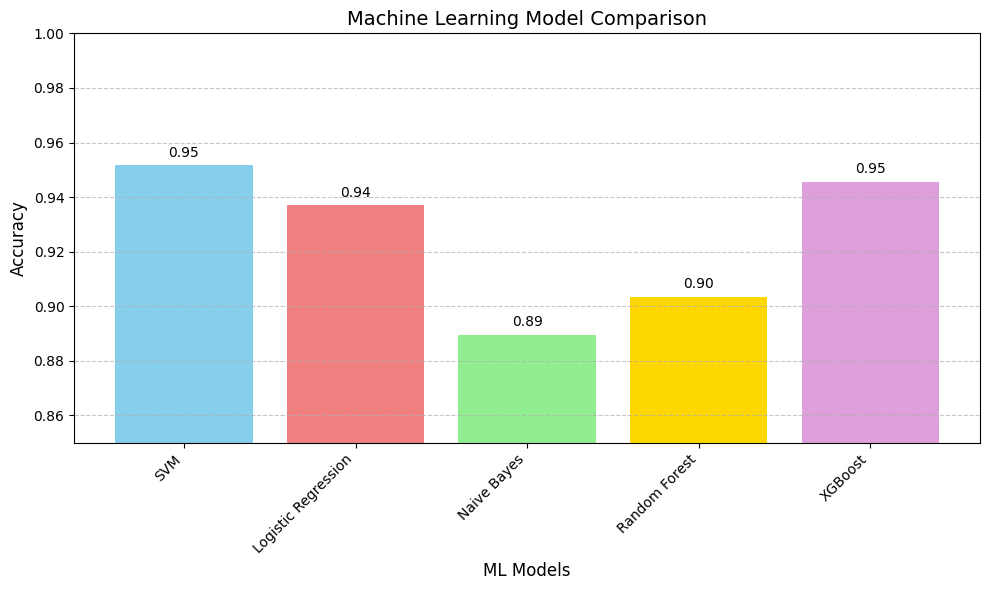

SVM: 95.17%
Logistic Regression: 93.70%
Naive Bayes: 88.96%
Random Forest: 90.34%


<Figure size 640x480 with 0 Axes>

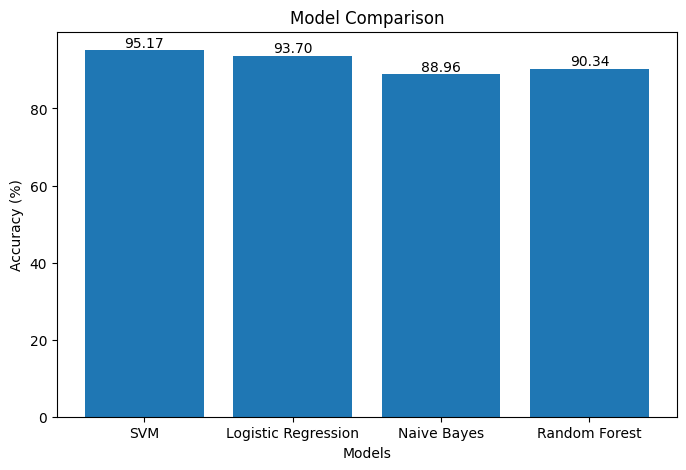

🧠 Mental Health Detection System
Type 'exit' to quit



In [ ]:


from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# ================== LOAD DATA ==================
df1 = pd.read_csv('/content/drive/My Drive/prDataset/Combined Data.csv')
df2 = pd.read_csv('/content/drive/My Drive/prDataset/dreaddit-train.csv')
df3 = pd.read_csv('/content/drive/My Drive/prDataset/dreaddit-test.csv')

import pandas as pd
import numpy as np
import re
import string
import gc

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

def standardize_label(label):
    if isinstance(label, str):
        label = label.lower()
        if label in ["normal", "no stress", "no anxiety"]:
            return 0
        else:
            return 1
    return int(label)

df1 = df1[['statement', 'status']].rename(columns={'statement': 'text', 'status': 'label'})
df2 = df2[['text', 'label']]
df3 = df3[['text', 'label']]

df = pd.concat([df1, df2, df3], ignore_index=True)
df['label'] = df['label'].apply(standardize_label)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

word_vectorizer = TfidfVectorizer(
    max_features=30000,          # ↑ increase slightly
    ngram_range=(1,3),           # 🔥 big improvement
    stop_words='english',
    min_df=3,
    max_df=0.85,
    sublinear_tf=True            # 🔥 important
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,6),           # better patterns
    max_features=15000
)

X_train_vec = hstack([
    word_vectorizer.fit_transform(X_train),
    char_vectorizer.fit_transform(X_train)
])

X_test_vec = hstack([
    word_vectorizer.transform(X_test),
    char_vectorizer.transform(X_test)
])

from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=20000)

X_train_vec = selector.fit_transform(X_train_vec, y_train)
X_test_vec = selector.transform(X_test_vec)

from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

X_train_vec = scaler.fit_transform(X_train_vec)
X_test_vec = scaler.transform(X_test_vec)

X_train_word = word_vectorizer.fit_transform(X_train)
X_test_word = word_vectorizer.transform(X_test)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

# Combine
X_train_vec = hstack([X_train_word, X_train_char])
X_test_vec = hstack([X_test_word, X_test_char])

from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define models before using them in the dictionary
svm_model = LinearSVC(
    C=3.0,
    max_iter=5000,
    class_weight='balanced'
)
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

models = {
    "SVM": svm_model,

    "Logistic Regression": lr,

    "Naive Bayes": MultinomialNB(alpha=0.5),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='logloss',
        random_state=42
    )


}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

    gc.collect()

print("\n📊 Model Comparison:\n")

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

best_model_name = max(results, key=results.get)

print("\n🏆 Best Model:", best_model_name)

best_model = models[best_model_name]

best_model.fit(X_train_vec, y_train)

y_pred_final = best_model.predict(X_test_vec)

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred_final))

def predict(text):
    text = clean_text(text)

    vec = hstack([
        word_vectorizer.transform([text]),
        char_vectorizer.transform([text])
    ])

    pred = best_model.predict(vec)[0]

    return "Stress/Anxiety" if pred == 1 else "Normal"

import matplotlib.pyplot as plt

# Define results_ml (ensure this is executed after vnum6KfF6FkY)
results_ml = results # Use the already computed results dictionary

plot_model_names = list(results_ml.keys())
accuracies = list(results_ml.values())

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
plt.bar(plot_model_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum'])

plt.xlabel("ML Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Machine Learning Model Comparison", fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.85, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()
plt.savefig('ml_model_comparison.png') # Save the plot as a PNG image

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

models = {
    "SVM": svm_model,
    "Logistic Regression": lr,
    "Naive Bayes": MultinomialNB(alpha=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=15, n_jobs=-1, random_state=42)
}

names = []
scores = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred) * 100
    names.append(name)
    scores.append(acc)
    print(f"{name}: {acc:.2f}%")

plt.figure(figsize=(8,5))
plt.bar(names, scores)

for i in range(len(names)):
    plt.text(i, scores[i], f"{scores[i]:.2f}", ha='center', va='bottom')

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')

plt.show()

def get_level(percent):
    if percent >= 70:
        return "High"
    elif percent >= 40:
        return "Moderate"
    elif percent > 0:
        return "Low"
    else:
        return "None"


def predict_mental_state(text):

    text_clean = clean_text(text)

    # ✅ Vectorization
    vec_word = word_vectorizer.transform([text_clean])
    vec_char = char_vectorizer.transform([text_clean])
    vec = hstack([vec_word, vec_char])

    prediction = model.predict(vec)[0]

    # 🔹 WORD LISTS

    anxiety_words = [
        "anxious","anxiety","panic","panic attack","worried","worry","fear",
        "nervous","restless","uneasy","on edge","jittery","shaky",
        "heart racing","racing heart","palpitations","sweating","trembling",
        "overthinking","racing thoughts","intrusive thoughts",
        "constant worry","can't stop thinking","cant stop thinking",
        "thinking too much","fear of worst","catastrophic thinking",
        "dread","apprehensive","paranoid","insecure","fearful",
        "uneasiness","disturbed","mental tension","overwhelmed with fear",
        "social anxiety","fear of judgement","fear of people",
        "fear of speaking","public speaking fear","social fear",
        "tight chest","shortness of breath","breathing fast",
        "choking feeling","dizziness","lightheaded",
        "butterflies in stomach","nausea","sweaty palms",
        "avoidance","avoiding people","avoiding situations",
        "can't relax","cant relax","difficulty relaxing",
        "insomnia","trouble sleeping","cant sleep","can't sleep",
        "night anxiety","waking up anxious",
        "fear of future","uncertain","uncertainty","what if",
        "fear of failure","fear of losing","fear of unknown",
        "i feel anxious","i am anxious","i am worried",
        "i feel nervous","i am scared","i feel panic",
        "i can't calm down","i cant calm down",
        "something bad will happen","i feel unsafe"
    ]


    positive_words = [
        "happy","joy","joyful","excited","good","great","fine","okay",
        "relaxed","calm","peaceful","content","satisfied","at ease",
        "comfortable","chill","serene","tranquil",
        "awesome","fantastic","amazing","wonderful","excellent",
        "brilliant","superb","lovely","delighted","thrilled",
        "confident","motivated","hopeful","optimistic","positive",
        "inspired","determined","encouraged","focused",
        "stable","balanced","mentally strong","feeling good",
        "doing well","all good","everything is fine",
        "feeling better","getting better","recovering",
        "grateful","thankful","blessed","loved","supported",
        "connected","cared","appreciated",
        "enjoying life","having fun","living well","peace of mind",
        "no stress","stress free","feeling relaxed",
        "life is good","i feel good","i am happy","i am fine",
        "everything is going well","things are good",
        "i feel relaxed","i am okay","doing great"
    ]


    stress_words = [
        "stress","stressed","pressure","overwhelmed","burnout",
        "exhausted","tired","fatigue","drained","worn out",
        "low energy","no energy","mentally drained","physically tired",
        "frustrated","irritated","irritation","annoyed","angry",
        "upset","disturbed","fed up","losing patience",
        "workload","deadline","deadlines","burden","too much work",
        "assignment pressure","exam pressure","academic pressure",
        "work stress","job stress","project stress",
        "can't cope","cant cope","too much","overloaded","breakdown",
        "losing control","out of control","handling too much",
        "unable to focus","lack of focus","confused mind",
        "no sleep","lack of sleep","sleep deprived","busy schedule",
        "no time","time pressure","tight schedule",
        "headache","tension headache","body pain","back pain",
        "neck pain","muscle tension","restless","uneasy",
        "burned out","feeling stuck","stuck in life",
        "nothing is working","everything is going wrong",
        "feeling overwhelmed","too many responsibilities",
        "i am stressed","i feel stressed","i am overwhelmed",
        "i cant handle this","this is too much",
        "i am tired of everything","i am mentally tired"
    ]


    severe_words = [
        "suicide","kill myself","end my life","want to die","dying",
        "i want to die","i wish i was dead","i dont want to live",
        "i don't want to live","i cant go on","i can't go on",
        "self harm","self-harm","cut myself","hurting myself",
        "harm myself","i cut myself","injure myself",
        "hopeless","helpless","worthless","useless","no hope",
        "lost all hope","nothing matters","no purpose",
        "life is pointless","meaningless life","empty inside",
        "feeling dead inside","completely broken","emotionally broken",
        "i feel empty","i feel numb","numb","dead inside",
        "give up on life","giving up","no future","no reason to live",
        "no reason to go on","better off dead","tired of living",
        "cant take it anymore","can't take it anymore",
        "i feel alone","completely alone","no one cares",
        "no one understands me","nobody cares","abandoned",
        "want to disappear","wish to disappear","disappear forever",
        "vanish","i should disappear",
        "i hate my life","i hate everything","everything is pointless",
        "nothing is worth it","life is useless",
        "end everything","finish everything","this is the end",
        "i am done with life","i am done","no way out"
    ]

    # 🔹 SCORES
    anxiety_score = sum(word in text_clean for word in anxiety_words)
    stress_score = sum(word in text_clean for word in stress_words)
    positive_score = sum(word in text_clean for word in positive_words)
    severe_score = sum(word in text_clean for word in severe_words)

    # 🔹 PERCENTAGES
    stress_percent = round((stress_score / len(stress_words)) * 100, 2)
    anxiety_percent = round((anxiety_score / len(anxiety_words)) * 100, 2)

    # 🔥 LEVELS
    stress_level = get_level(stress_percent)
    anxiety_level = get_level(anxiety_percent)

    # 🔹 FINAL STATE
    if severe_score > 0:
        state = "Severe Distress"
    elif anxiety_score > stress_score and anxiety_score > 0:
        state = f"Anxiety ({anxiety_level})"
    elif stress_score > 0:
        state = f"Stress ({stress_level})"
    elif positive_score > 0:
        state = "Normal"
    else:
        state = "Normal"

    return {
        "state": state,
        "stress_level": stress_level,
        "anxiety_level": anxiety_level,
        "stress_percentage": f"{stress_percent}%",
        "anxiety_percentage": f"{anxiety_percent}%",
        "advice": give_advice(state.split(" ")[0])
    }

# ================== LEVEL FUNCTION ==================
def get_level(percent):
    if percent >= 70:
        return "High"
    elif percent >= 40:
        return "Moderate"
    elif percent > 0:
        return "Low"
    else:
        return "None"


# ================== ADVICE SYSTEM ==================
def give_advice(state):

    if state == "Normal":
        return [
            "Maintain a healthy lifestyle",
            "Exercise regularly (at least 30 minutes)",
            "Get 7–8 hours of quality sleep",
            "Stay socially connected with friends and family",
            "Practice gratitude and positive thinking",
            "Maintain a balanced diet",
            "Limit screen time",
            "Engage in hobbies or creative activities"
        ]

    elif state == "Stress":
        return [
            "Take regular breaks (Pomodoro technique)",
            "Reduce workload and prioritize tasks",
            "Practice relaxation techniques (yoga, stretching)",
            "Time management and planning",
            "Listen to calming music",
            "Avoid multitasking",
            "Go for short walks or physical activity",
            "Talk to friends or mentors",
            "Maintain proper sleep schedule"
        ]

    elif state == "Anxiety":
        return [
            "Practice deep breathing exercises",
            "Try mindfulness and meditation",
            "Reduce caffeine and sugar intake",
            "Limit overthinking by focusing on present",
            "Write down thoughts (journaling)",
            "Engage in grounding techniques (5-4-3-2-1 method)",
            "Seek social support",
            "Practice progressive muscle relaxation",
            "Maintain a consistent daily routine"
        ]

    elif state == "Severe Distress":
        return [
            "Seek immediate professional help",
            "Consult a psychologist or psychiatrist",
            "Contact a mental health helpline",
            "Talk to a trusted person (family/friend)",
            "Do not stay alone during difficult moments",
            "Avoid harmful substances (alcohol, drugs)",
            "Follow a safety plan",
            "Reach out to emergency services if needed",
            "Practice self-care under supervision"
        ]


# ================== PREDICTION ==================
def predict_mental_state(text):

    text_clean = clean_text(text)

    # ✅ Vectorization
    vec_word = word_vectorizer.transform([text_clean])
    vec_char = char_vectorizer.transform([text_clean])
    vec = hstack([vec_word, vec_char])

    prediction = model.predict(vec)[0]

    # 🔹 WORD LISTS
    anxiety_words = ["anxious","anxiety","panic","worried","fear","nervous","restless"]
    stress_words = ["stress","stressed","pressure","overwhelmed","burnout","tired","fatigue"]
    positive_words = ["happy","relaxed","calm","peaceful","good","fine"]
    severe_words = ["suicide","kill myself","want to die","self harm","hopeless"]

    # 🔹 SCORES
    anxiety_score = sum(word in text_clean for word in anxiety_words)
    stress_score = sum(word in text_clean for word in stress_words)
    positive_score = sum(word in text_clean for word in positive_words)
    severe_score = sum(word in text_clean for word in severe_words)

    # 🔹 PERCENTAGES
    stress_percent = round((stress_score / len(stress_words)) * 100, 2)
    anxiety_percent = round((anxiety_score / len(anxiety_words)) * 100, 2)

    # 🔥 LEVELS
    stress_level = get_level(stress_percent)
    anxiety_level = get_level(anxiety_percent)

    # 🔹 FINAL STATE (IMPROVED)
    if severe_score > 0:
        state = "Severe Distress"
    elif anxiety_score > stress_score and anxiety_score > 0:
        state = "Anxiety"
    elif stress_score > 0:
        state = "Stress"
    elif positive_score > 0:
        state = "Normal"
    else:
        state = "Normal"

    # 🔹 RETURN OUTPUT
    return {
        "state": state,
        "stress_level": stress_level,
        "anxiety_level": anxiety_level,
        "stress_percentage": f"{stress_percent}%",
        "anxiety_percentage": f"{anxiety_percent}%",
        "advice": give_advice(state)
    }

# ================== USER LOOP ==================
if __name__ == "__main__":

    print("🧠 Mental Health Detection System")
    print("Type 'exit' to quit\n")

    while True:
        user_text = input("Enter your thoughts: ")

        # 🔥 EXIT CONDITION
        if user_text.lower() in ["exit", "quit", "bye"]:
            print("👋 Exiting... Take care!")
            break

        # 🔥 EMPTY INPUT CHECK
        if user_text.strip() == "":
            print("⚠ Please enter some text\n")
            continue

        # 🔥 PREDICTION
        result = predict_mental_state(user_text)

        print("\n📊 RESULT")
        print("State:", result["state"])
        print("Stress Level:", result["stress_level"], f"({result['stress_percentage']})")
        print("Anxiety Level:", result["anxiety_level"], f"({result['anxiety_percentage']})")

        print("\n💡 Advice:")
        for adv in result["advice"]:
            print("-", adv)

        print("\n" + "="*50 + "\n")